# Practical - steer Snake with your thumb

You will train a CNN that reads **which way your thumb points** in a webcam crop - up, down,
left, right, or nothing - and then play Snake with it (`play_snake.py`).

| Part | What you do |
|---|---|
| 1 | look at your own recordings |
| 2 | split by **burst**, not at random |
| 3 | an augmentation that **changes the label** |
| 4 | a small CNN from scratch, and where it fails |
| 5 | Grad-CAM: is it looking at your thumb? (L18) |
| 6 | the random-split trap, measured |
| 7 | transfer learning: frozen ResNet-18 features + logistic regression (L18) |
| 8 | other people: does it work on strangers? |
| 9 | export the model and play |

**Before you start:** record your data (about 3 minutes, two bursts per class):

```
python record_gestures.py --user yourname
```

Everything runs on a laptop CPU. Seed `509`. A full run takes **about 3 minutes for 500 images on
2 CPU threads** (measured 157 s on the instructor's recordings). More recordings make it slower,
more cores faster.

The outputs saved in this notebook come from the **instructor's** recordings: 500 crops, 2 bursts
per class. The notes after the results describe that run - yours will differ.

## Setup

`gesture_common.py` is shared by the recorder, this notebook and the game: the class list, the
crop, and the image-to-tensor conversion all come from there, so the three can never disagree.

In [1]:
# ~12 s: the first import of torch, plotly and sklearn is slow
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

from gesture_common import CLASSES, CROP_SIZE, bgr_to_tensor, imread_u, parse_name

SEED = 509
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
DATA = Path("gesture_data")
ARM_RED, ARM_BLUE, ARM_ORANGE = "#D90012", "#0033A0", "#F2A800"
print("classes:", CLASSES, "| crop:", CROP_SIZE, "px | torch", torch.__version__)

classes: ('up', 'down', 'left', 'right', 'nothing') | crop: 128 px | torch 2.9.0+cpu


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1 - your data

Every file name carries three facts: `gesture_data/<user>/<class>/<user>_<burst>_<nn>.jpg`.
The **burst** is one key press in the recorder: 50 frames taken over about 5 seconds.

In [2]:
files = sorted(DATA.glob("*/*/*.jpg"))
if not files:
    raise FileNotFoundError(f"no images under {DATA.resolve()} - run record_gestures.py first")
meta = [parse_name(f) for f in files]
X = np.stack([imread_u(f) for f in files])                  # (N, 128, 128, 3), uint8, BGR
y = np.array([CLASSES.index(c) for _, _, c in meta], dtype=np.int64)  # int64: what the loss wants
users = np.array([u for u, _, _ in meta])
bursts = np.array([f"{u}/{c}/{b}" for u, b, c in meta])
missing = [c for c in CLASSES if c not in {m[2] for m in meta}]
if missing:
    raise ValueError(f"no recordings for {missing} - record every class")
print(f"{len(X)} images, {X.nbytes / 1e6:.0f} MB in memory, {len(set(bursts))} bursts, "
      f"{len(set(users))} user(s)")

500 images, 25 MB in memory, 10 bursts, 1 user(s)


How many images per user and class:

In [3]:
pd.crosstab(pd.Series(users, name="user"),
            pd.Series([CLASSES[k] for k in y], name="class"))[list(CLASSES)]

class,up,down,left,right,nothing
user,,,,,
hayk,100,100,100,100,100


Eight random crops per class. This is exactly what the model will see - the green box of the
recorder, mirrored like a selfie.

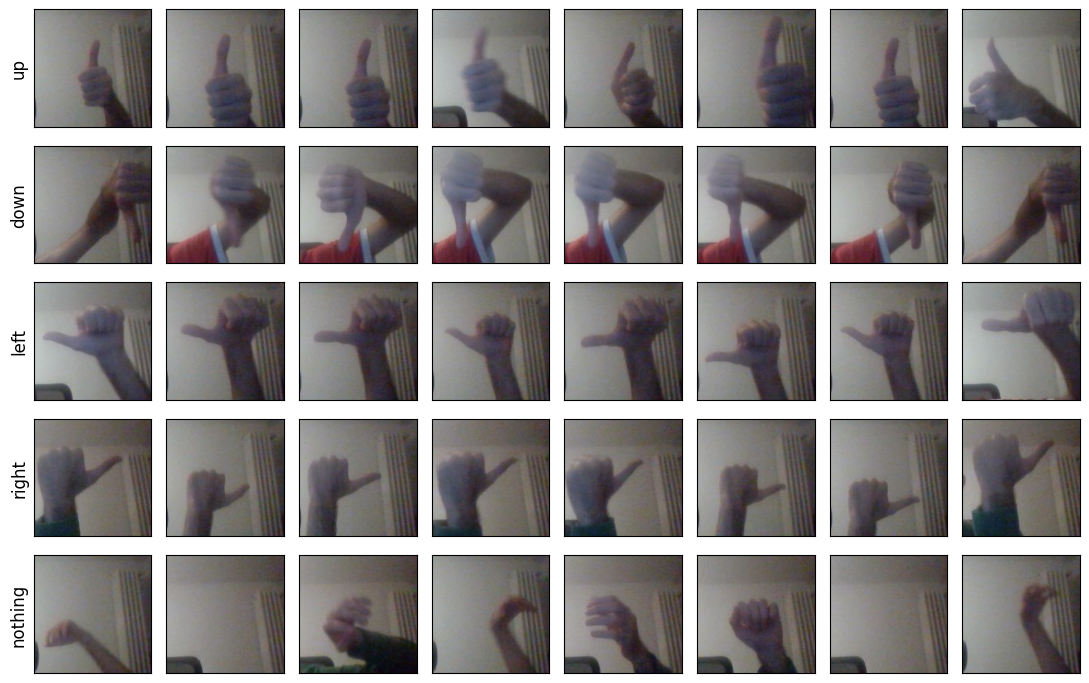

In [4]:
# ~3 s
fig, axes = plt.subplots(len(CLASSES), 8, figsize=(11, 7))
for r, c in enumerate(CLASSES):
    pick = rng.choice(np.where(y == r)[0], 8, replace=False)
    for ax, i in zip(axes[r], pick):
        ax.imshow(X[i][..., ::-1]); ax.set_xticks([]); ax.set_yticks([])
    axes[r, 0].set_ylabel(c, fontsize=12)
plt.tight_layout(); plt.show()

## Part 2 - split by burst

Frames inside one burst are a tenth of a second apart: near-copies. If a random split puts one
frame in training and its neighbour in validation, the validation score measures **memory**, not
skill. (The popular Kaggle ASL alphabet set is 3,000 consecutive video frames per letter, one
signer, one room; models that look near-perfect on it are reported to fail on new backgrounds.)

So we hold out **whole bursts**: for every user and class, the last burst goes to validation.

In [5]:
def burst_split(users, y, bursts):
    # returns (train indices, validation indices): the last burst of every user and class validates
    val_mask = np.zeros(len(y), dtype=bool)
    for u in np.unique(users):
        for k, c in enumerate(CLASSES):
            bs = sorted(set(bursts[(users == u) & (y == k)]))
            if len(bs) < 2:
                raise ValueError(f"{u}/{c} has {len(bs)} burst(s) - record at least 2 so one can be held out")
            val_mask |= bursts == bs[-1]
    return np.where(~val_mask)[0], np.where(val_mask)[0]


tr, va = burst_split(users, y, bursts)
assert not set(bursts[tr]) & set(bursts[va]), "a burst must never be on both sides"
print(f"train {len(tr)} images | validation {len(va)} images (whole bursts)")

train 250 images | validation 250 images (whole bursts)


## Part 3 - an augmentation that changes the label

In [43], flipping an image was free extra data: a mirrored cat is still a cat. Here a mirrored
**left** thumb is a **right** thumb - the flip is still free data, but the label has to flip with
it. `FLIP[k]` is the class that class `k` becomes in the mirror.

In [6]:
FLIP = torch.tensor([CLASSES.index({"left": "right", "right": "left"}.get(c, c)) for c in CLASSES])
print({c: CLASSES[int(j)] for c, j in zip(CLASSES, FLIP)})


def mirror_batch(xb, yb):
    # mirror every image left-right, and give each one the label it has in the mirror
    return xb.flip(3), FLIP[yb]

{'up': 'up', 'down': 'down', 'left': 'right', 'right': 'left', 'nothing': 'nothing'}


Check it on one `left` crop: the mirrored picture must be labelled `right`, and mirroring twice
must give back the original.

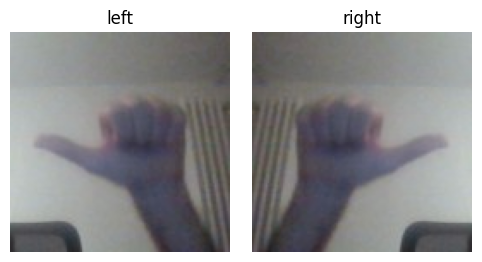

In [7]:
i_left = np.where(y == CLASSES.index("left"))[0][0]
x1, y1 = bgr_to_tensor(X[i_left]), torch.tensor([y[i_left]])
xm, ym = mirror_batch(x1, y1)
assert CLASSES[int(ym)] == "right" and torch.equal(xm, x1.flip(3))
assert torch.equal(mirror_batch(xm, ym)[0], x1) and int(mirror_batch(xm, ym)[1]) == int(y1)
fig, axes = plt.subplots(1, 2, figsize=(5, 2.6))
for ax, img, lab in [(axes[0], x1, y1), (axes[1], xm, ym)]:
    ax.imshow(img[0].permute(1, 2, 0)); ax.set_title(CLASSES[int(lab)]); ax.axis("off")
plt.tight_layout(); plt.show()

The full augmentation: mirror half the batch (and swap the labels), change brightness and
contrast (your room at 9 am is not your room at 9 pm), and shift each crop by up to 8 pixels
(your hand is never in exactly the same spot).

In [8]:
def augment(xb, yb, pad=8):
    # xb: (B, 3, H, W) in [0, 1], yb: (B,) class indices
    flip = torch.rand(len(xb)) < 0.5
    xm, ym = mirror_batch(xb, yb)
    xb = torch.where(flip[:, None, None, None], xm, xb)
    yb = torch.where(flip, ym, yb)
    gain = torch.empty(len(xb), 1, 1, 1).uniform_(0.7, 1.3)
    bias = torch.empty(len(xb), 1, 1, 1).uniform_(-0.1, 0.1)
    xb = (xb * gain + bias).clamp(0, 1)
    H, W = xb.shape[2:]
    xp = F.pad(xb, (pad,) * 4, mode="replicate")
    off = torch.randint(0, 2 * pad + 1, (len(xb), 2))
    xb = torch.stack([xp[k, :, i:i + H, j:j + W] for k, (i, j) in enumerate(off.tolist())])
    return xb, yb

## Part 4 - a small CNN

The crop is 128 px; a thumb is obvious at 64 px, so the net first **averages 2x2 blocks** (a
pooling layer with no weights, L16). Then three conv blocks (conv, BatchNorm, ReLU, max-pool), each
halving the map and doubling the channels, down to 64 maps of 8x8.

The head is a dense layer on the **flattened** 8x8x64 maps, not L17's global average pool. A
global average pool keeps only "how much of each feature", and which way a thumb points is a
question about *where*: which side of the fist the thumb sticks out.

In [9]:
def small_cnn():
    def block(cin, cout):
        return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                             nn.ReLU(), nn.MaxPool2d(2))
    return nn.Sequential(nn.AvgPool2d(2),                                  # 128 -> 64 px
                         block(3, 16), block(16, 32), block(32, 64),       # 64 -> 32 -> 16 -> 8 px
                         nn.Flatten(), nn.Linear(64 * 8 * 8, len(CLASSES)))

print(f"{sum(p.numel() for p in small_cnn().parameters()):,} parameters")

44,293 parameters


Check that count with L16's formula, $k \cdot k \cdot C_{in} \cdot C_{out} + C_{out}$ per conv, plus
$2 C$ per BatchNorm ($\gamma$, $\beta$) and $64 \cdot 8 \cdot 8 \cdot 5 + 5$ for the head:

In [10]:
conv = lambda k, cin, cout: k * k * cin * cout + cout
by_hand = conv(3, 3, 16) + conv(3, 16, 32) + conv(3, 32, 64) + 2 * (16 + 32 + 64) + 64 * 8 * 8 * 5 + 5
assert by_hand == sum(p.numel() for p in small_cnn().parameters()), "the formula and the model disagree"
print(f"{by_hand:,} - almost half of them in the head")

44,293 - almost half of them in the head


The training loop is [42]'s, unchanged. `predict` returns the predicted class of every image in
an array.

In [11]:
def batches(idx, bs, shuffle):
    idx = rng.permutation(idx) if shuffle else idx
    for s in range(0, len(idx), bs):
        yield idx[s:s + bs]


def predict(model, imgs, bs=256):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(bgr_to_tensor(imgs[s:s + bs])).argmax(1)
                          for s in range(0, len(imgs), bs)]).numpy()


def train(model, tr_idx, va_idx, epochs=20, lr=2e-3, bs=32, desc="train"):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    hist = []
    for ep in tqdm(range(epochs), desc=desc):
        model.train()
        total, n = 0.0, 0
        for b in batches(tr_idx, bs, True):
            xb, yb = augment(bgr_to_tensor(X[b]), torch.from_numpy(y[b]))
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            total, n = total + loss.item() * len(b), n + len(b)
        hist.append({"epoch": ep + 1, "train loss": total / n,
                     "val accuracy": float((predict(model, X[va_idx]) == y[va_idx]).mean())})
    return pd.DataFrame(hist)

Train it.

In [12]:
# ~1 min for 250 training crops on 2 CPU threads (measured 62 s); more recordings, longer
torch.manual_seed(SEED)
cnn = small_cnn()
t0 = time.perf_counter()
hist = train(cnn, tr, va, desc="small CNN")
acc_cnn = hist["val accuracy"].iloc[-1]
best = hist.loc[hist["val accuracy"].idxmax()]
print(f"trained in {time.perf_counter() - t0:.0f} s; validation accuracy after the last epoch {acc_cnn:.1%}, "
      f"best {best['val accuracy']:.1%} (epoch {int(best['epoch'])})")

small CNN:   0%|          | 0/20 [00:00<?, ?it/s]

small CNN:   5%|▌         | 1/20 [00:02<00:42,  2.24s/it]

small CNN:  10%|█         | 2/20 [00:04<00:45,  2.51s/it]

small CNN:  15%|█▌        | 3/20 [00:08<00:46,  2.76s/it]

small CNN:  20%|██        | 4/20 [00:10<00:40,  2.55s/it]

...

small CNN:  90%|█████████ | 18/20 [00:38<00:03,  1.63s/it]

small CNN:  95%|█████████▌| 19/20 [00:40<00:01,  1.71s/it]

small CNN: 100%|██████████| 20/20 [00:42<00:00,  1.79s/it]

small CNN: 100%|██████████| 20/20 [00:42<00:00,  2.10s/it]

trained in 46 s; validation accuracy after the last epoch 27.2%, best 78.4% (epoch 13)


Training loss and validation accuracy per epoch:

In [13]:
fig = go.Figure()
fig.add_scatter(x=hist["epoch"], y=hist["train loss"], name="train loss", line_color=ARM_BLUE)
fig.add_scatter(x=hist["epoch"], y=hist["val accuracy"], name="val accuracy", yaxis="y2",
                line_color=ARM_RED)
fig.update_layout(height=320, xaxis_title="epoch", yaxis_title="train loss",
                  yaxis2=dict(title="val accuracy", overlaying="y", side="right", range=[0, 1]),
                  margin=dict(t=20))
fig.show()

**On the instructor's recordings.** Training loss drops to almost zero: the net memorized its
training burst. Validation accuracy jumps around from epoch to epoch - 78.4% at its best, 27.2%
after the last epoch - so the number after the last epoch is luck.

Why so jumpy: the validation set is 250 crops but only **5 bursts**, and the 50 frames of a burst
are near-copies, so a whole class flips at once. Keeping the best epoch would mean choosing on the
validation set, and then the 78.4% is no longer an honest test score - that needs a third burst.

Accuracy hides *which* mistakes. The confusion matrix on the held-out bursts ([12]):

In [14]:
pred_va = predict(cnn, X[va])
cm = pd.crosstab(pd.Series([CLASSES[k] for k in y[va]], name="true"),
                 pd.Series([CLASSES[k] for k in pred_va], name="predicted")).reindex(
                 index=list(CLASSES), columns=list(CLASSES), fill_value=0)
fig = go.Figure(go.Heatmap(z=cm.values, x=list(CLASSES), y=list(CLASSES), text=cm.values,
                           texttemplate="%{text}", colorscale="Blues", showscale=False))
fig.update_layout(height=360, width=420, xaxis_title="predicted", yaxis_title="true",
                  yaxis_autorange="reversed", margin=dict(t=20))
fig.show()

The mistakes themselves - look at them before you change anything:

182 of 250 validation crops wrong


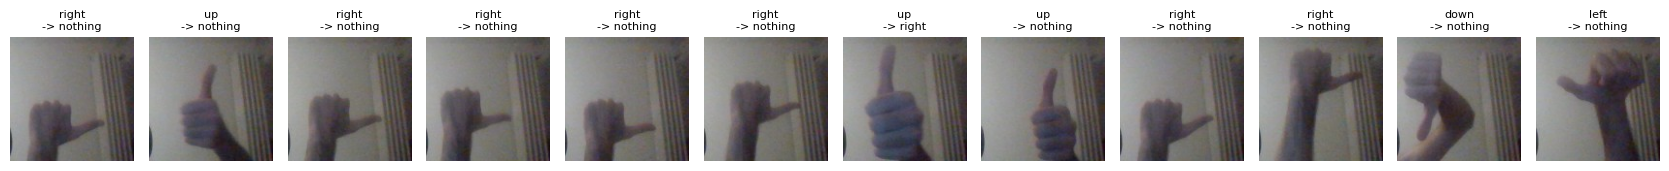

In [15]:
wrong = np.where(pred_va != y[va])[0]          # positions inside va
print(f"{len(wrong)} of {len(va)} validation crops wrong")
show = rng.choice(wrong, min(12, len(wrong)), replace=False) if len(wrong) else []
if len(show):
    fig, axes = plt.subplots(1, len(show), figsize=(1.4 * len(show), 1.9), squeeze=False)
    for ax, k in zip(axes[0], show):
        ax.imshow(X[va[k]][..., ::-1]); ax.axis("off")
        ax.set_title(f"{CLASSES[y[va[k]]]}\n-> {CLASSES[pred_va[k]]}", fontsize=8)
    plt.tight_layout(); plt.show()

**On the instructor's recordings** almost every mistake is "-> nothing", on crops where the thumb
is plain to see.

## Part 5 - Grad-CAM: is it looking at your thumb?

L18's audit, on your model. High accuracy is not the same as right reasons: a model can learn that
"left" crops happen to show more of your sleeve. Grad-CAM's three steps, as in L18:

1. take the feature maps of the **last conv block** (here 64 maps of 16x16, before the last pool);
2. weight each map by the **average gradient** of the predicted class score with respect to it;
3. sum, ReLU, upsample to the crop size.

In [16]:
def gradcam(model, img, layer):
    # img: one BGR crop. Returns (heatmap in [0, 1] of the crop's size, predicted class index)
    store = {}
    hook = layer.register_forward_hook(lambda m, inp, out: store.__setitem__("A", out))
    model.eval()
    try:
        logits = model(bgr_to_tensor(img))
    finally:
        hook.remove()
    k = int(logits.argmax())
    A = store["A"]                                           # (1, 64, 16, 16)
    grad, = torch.autograd.grad(logits[0, k], A)
    cam = F.relu((grad.mean(dim=(2, 3), keepdim=True) * A).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=img.shape[:2], mode="bilinear")[0, 0].detach()
    return (cam / (cam.max() + 1e-8)).numpy(), k


last_relu = cnn[3][2]    # block 3 = (conv, BatchNorm, ReLU, max-pool): the ReLU's output

Two held-out crops per class, with the heatmap on top. Red = the evidence the prediction rests on.

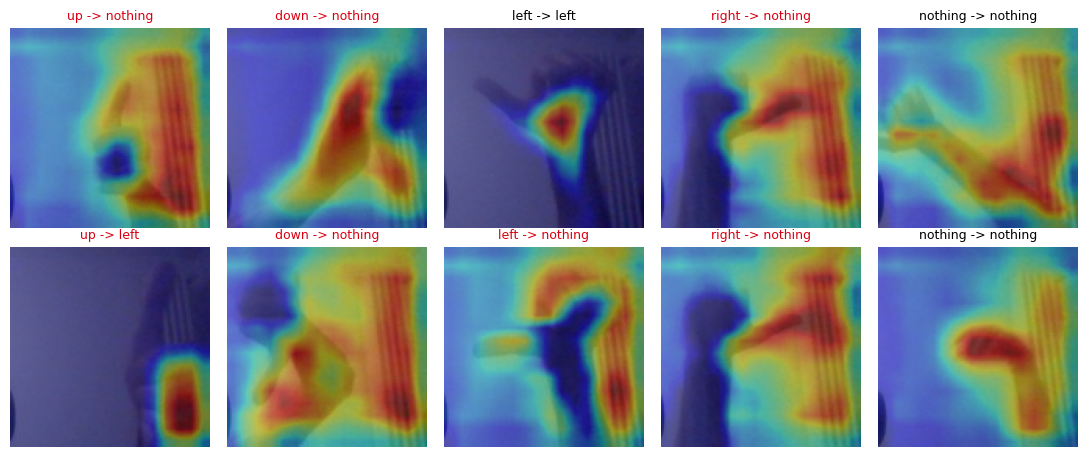

In [17]:
# ~3 s
fig, axes = plt.subplots(2, len(CLASSES), figsize=(11, 4.6))
for c_idx, c in enumerate(CLASSES):
    for row, i in enumerate(rng.choice(va[y[va] == c_idx], 2, replace=False)):
        cam, k = gradcam(cnn, X[i], last_relu)
        ax = axes[row, c_idx]
        ax.imshow(X[i][..., ::-1]); ax.imshow(cam, cmap="jet", alpha=0.45); ax.axis("off")
        ax.set_title(f"{c} -> {CLASSES[k]}", fontsize=9, color="black" if k == c_idx else ARM_RED)
plt.tight_layout(); plt.show()

**On the instructor's recordings** the heat sits mostly on the **radiator** at the edge of the box and
on the **forearm**, not on the thumb. The crops where it does look at the hand are the ones it gets
right. The first bursts also carried shortcuts planted on purpose - a red sleeve only in "down", a
dark green one only in "right". The second bursts have neither, the familiar clues are gone, and
the model falls back to "nothing": right answers on the first burst, for the wrong reasons.

## Part 6 - the random-split trap, measured

Take a model with **no understanding at all**: 1-nearest-neighbour on raw pixels (the classic
methods chapter). It answers with the label of the single most similar training crop - pure
memory. Score it twice: validation frames drawn **at random** (every one has near-copies in
training), and the burst split from Part 2.

In [18]:
# ~7 s
from sklearn.neighbors import KNeighborsClassifier

pix = F.avg_pool2d(bgr_to_tensor(X), 4).flatten(1).numpy()     # 32 x 32 x 3 = 3,072 numbers per crop
perm = rng.permutation(len(y))
va_rand, tr_rand = perm[:len(va)], perm[len(va):]


def knn_accuracy(tr_idx, va_idx):
    return KNeighborsClassifier(n_neighbors=1).fit(pix[tr_idx], y[tr_idx]).score(pix[va_idx], y[va_idx])


acc_knn_rand, acc_knn_burst = knn_accuracy(tr_rand, va_rand), knn_accuracy(tr, va)
print(f"1-NN on pixels: random split {acc_knn_rand:.1%} | burst split {acc_knn_burst:.1%} "
      f"| small CNN, burst split {acc_cnn:.1%}")

1-NN on pixels: random split 100.0% | burst split 43.2% | small CNN, burst split 27.2%


The three numbers side by side:

In [19]:
names = ["1-NN, random split", "1-NN, burst split", "small CNN, burst split"]
vals = [acc_knn_rand, acc_knn_burst, acc_cnn]
fig = go.Figure(go.Bar(x=names, y=vals, marker_color=[ARM_RED, ARM_ORANGE, ARM_BLUE],
                       text=[f"{v:.1%}" for v in vals], textposition="outside"))
fig.update_layout(height=340, width=520, yaxis=dict(range=[0, 1.1], title="validation accuracy"),
                  margin=dict(t=20))
fig.show()

**On the instructor's recordings** pure memory scores 100.0% on the random split and 43.2% on the
burst split. A random split would have reported a perfect model; the burst split shows what is left
once the near-copies are gone.

## Part 7 - transfer learning: frozen ResNet-18 features

L18's Recipe 1. Freeze an ImageNet ResNet-18, drop its classifier, and use its 512-number output
as features for **logistic regression** ([11]) - a linear probe.

Two details from L18 matter here: the trunk stays in `eval()` mode (the BatchNorm gotcha), and
inputs are normalized with **ImageNet's** mean and std, not ours.

In [20]:
# ~2 s, plus a one-time 47 MB download of the ResNet-18 weights on the first run
from sklearn.linear_model import LogisticRegression
from torchvision.models import ResNet18_Weights, resnet18

trunk = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
trunk.fc = nn.Identity()
trunk.eval()
for p in trunk.parameters():
    p.requires_grad = False
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def features(imgs, flip=False, bs=128):
    out = []
    with torch.no_grad():
        for s in range(0, len(imgs), bs):
            xb = bgr_to_tensor(imgs[s:s + bs])
            out.append(trunk(((xb.flip(3) if flip else xb) - MEAN) / STD))
    return torch.cat(out).numpy()

Features are computed **once** - the trunk never changes, so there is nothing to recompute per
epoch. The mirror trick still works: features of the flipped crops, with swapped labels.

In [21]:
# ~20 s for 500 crops on 2 CPU threads (measured)
t0 = time.perf_counter()
F_tr = np.concatenate([features(X[tr]), features(X[tr], flip=True)])
y_tr = np.concatenate([y[tr], FLIP.numpy()[y[tr]]])
F_va = features(X[va])
print(f"features {F_tr.shape} + {F_va.shape} in {time.perf_counter() - t0:.0f} s")

features (500, 512) + (250, 512) in 18 s


Fit the logistic regression on the training features and score it on the held-out bursts:

In [22]:
probe = LogisticRegression(max_iter=3000, C=0.5).fit(F_tr, y_tr)
acc_probe = (probe.predict(F_va) == y[va]).mean()
print(f"ResNet-18 + logistic regression: {acc_probe:.1%} | small CNN: {acc_cnn:.1%}")

ResNet-18 + logistic regression: 64.4% | small CNN: 27.2%


**On the instructor's recordings** the frozen ResNet-18 rescues the task: 64.4% against the small
CNN's 27.2%. It learned to see from 1.2 million photos, so 250 crops only have to teach one linear
layer which of its features mean "thumb up" or "thumb left". Still far from perfect - one training
burst per class is very little - but it is the model that can play.

Accuracy is not the only cost in a game: every frame has to be classified before the next one
arrives. Time one crop through each model:

In [23]:
# ~3 s
x1 = bgr_to_tensor(X[va[:1]])
def ms_per_frame(f, reps=30):
    with torch.no_grad():
        f(x1); t0 = time.perf_counter()
        for _ in range(reps):
            f(x1)
    return (time.perf_counter() - t0) / reps * 1e3
cnn.eval()
print(f"small CNN {ms_per_frame(cnn):.1f} ms/frame | ResNet-18 {ms_per_frame(lambda x: trunk((x - MEAN) / STD)):.1f} ms/frame")

small CNN 4.6 ms/frame | ResNet-18 70.0 ms/frame


## Part 8 - other people

`web_sample/` holds 90 photos from HaGRID (a public gesture dataset): thumbs up, thumbs down,
and hands doing nothing - strangers, their rooms, and a looser framing than your green box.
No left or right in this sample.

In [24]:
# ~3 s
web_files = sorted(Path("web_sample").glob("*/*.jpg"))
Xw = np.stack([imread_u(f) for f in web_files])
yw = np.array([CLASSES.index(f.parent.name) for f in web_files])
acc_web_cnn = (predict(cnn, Xw) == yw).mean()
acc_web_probe = (probe.predict(features(Xw)) == yw).mean()
print(f"strangers ({len(Xw)} photos): small CNN {acc_web_cnn:.1%} | ResNet-18 probe {acc_web_probe:.1%}")

strangers (90 photos): small CNN 28.9% | ResNet-18 probe 34.4%


**On the instructor's recordings** neither model works on strangers: 28.9% and 34.4%, against 20% for
guessing. Trained on one person in one room, a model knows that person and that room. That is why
everyone trains on their own recordings.

## Part 9 - export and play

`torch.export` saves the model **with its computation graph**, so `play_snake.py` can load it
without knowing the class you wrote here. The contract (see `gesture_common.py`): a
`(N, 3, 128, 128)` RGB tensor in `[0, 1]` in, 5 logits out.

Export records the shapes of the example you give it. Marking dimension 0 as `Dim.DYNAMIC`
keeps the batch size free; the example holds **2** crops because with 1, export decides the
batch size is a constant and refuses.

In [25]:
def export(model, path):
    model.eval()
    example = torch.zeros(2, 3, CROP_SIZE, CROP_SIZE)
    ep = torch.export.export(model, (example,), dynamic_shapes=({0: torch.export.Dim.DYNAMIC},))
    torch.export.save(ep, path)

The ResNet-18 probe is two objects - a torch trunk and an sklearn logistic regression. To export it,
copy the regression's weights into an `nn.Linear` (a logistic regression **is** one linear layer
plus softmax, [11]) and put ImageNet's normalization inside the model, where the contract wants it.

In [26]:
# ~6 s
class ResNetProbe(nn.Module):
    def __init__(self, trunk, probe):
        super().__init__()
        if list(probe.classes_) != list(range(len(CLASSES))):
            raise ValueError(f"probe classes {probe.classes_} do not match CLASSES")
        self.trunk, self.head = trunk, nn.Linear(512, len(CLASSES))
        with torch.no_grad():
            self.head.weight.copy_(torch.from_numpy(probe.coef_).float())
            self.head.bias.copy_(torch.from_numpy(probe.intercept_).float())
        self.register_buffer("mean", MEAN.clone())
        self.register_buffer("std", STD.clone())

    def forward(self, x):
        return self.head(self.trunk((x - self.mean) / self.std))


resnet_model = ResNetProbe(trunk, probe).eval()
agree = (predict(resnet_model, X[va]) == probe.predict(F_va)).mean()
assert agree > 0.99, f"the torch copy of the probe disagrees with sklearn on {1 - agree:.1%} of crops"
print(f"torch copy agrees with sklearn on {agree:.1%} of validation crops")

torch copy agrees with sklearn on 100.0% of validation crops


Export both. `gesture_model.pt2` - the file the game loads by default - is whichever scored higher
on the held-out bursts; the other stays available with `python play_snake.py --model ...`.

In [27]:
# ~20 s: exporting and re-checking both models
import shutil
from play_snake import load_model

candidates = {"gesture_model_cnn.pt2": (cnn, acc_cnn), "gesture_model_resnet.pt2": (resnet_model, acc_probe)}
for path, (model, acc) in candidates.items():
    export(model, path)
    reloaded = load_model(Path(path))
    with torch.no_grad():
        same = (reloaded(bgr_to_tensor(X[va])).argmax(1).numpy() == predict(model, X[va])).mean()
    assert same > 0.99, f"{path}: the exported model disagrees with the original on {1 - same:.1%} of crops"
    print(f"{path}: validation {acc:.1%}, exported copy agrees on {same:.1%}")
best = max(candidates, key=lambda p: candidates[p][1])
shutil.copyfile(best, "gesture_model.pt2")
print(f"gesture_model.pt2 <- {best}")

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\torch\export\pt2_archive\_package.py:682: UserWarning:

The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:1587.)



gesture_model_cnn.pt2: validation 27.2%, exported copy agrees on 100.0%


gesture_model_resnet.pt2: validation 64.4%, exported copy agrees on 100.0%


gesture_model.pt2 <- gesture_model_resnet.pt2


Now play:

```
python play_snake.py
```